# 02. Exploratory Data Analysis (EDA) Notebook
**Owner:** Ravi (Data Cleaning & EDA Engineer)  
**Objective:** Analyze customer demographics, contract types, tenure, and monthly charges to identify key churn drivers.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_PATH = os.path.join("..", "data", "processed", "customer_features.csv")
df = pd.read_csv(PROCESSED_PATH)
print(f"[SUCCESS] Loaded {len(df)} customer records for EDA!")

[SUCCESS] Loaded 7043 customer records for EDA!


### 1. Overall Customer Churn Rate Distribution
Visualizing the proportion of active customers vs. churned customers across the company.

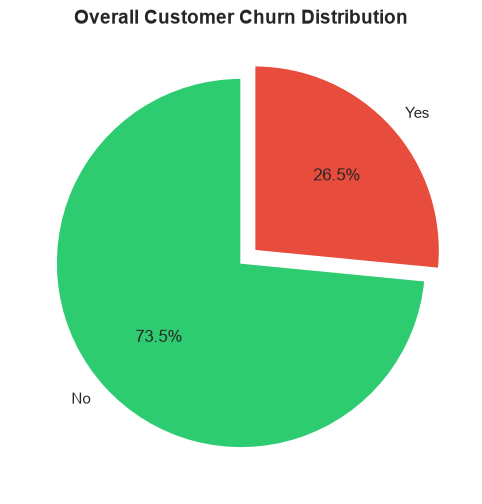

In [3]:
plt.figure(figsize=(6, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(
    churn_counts, 
    labels=churn_counts.index, 
    autopct='%1.1f%%', 
    colors=['#2ecc71', '#e74c3c'], 
    startangle=90, 
    explode=(0, 0.1)
)
plt.title('Overall Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.show()

### 2. Impact of Contract Type on Churn Risk
Comparing churn rates across Month-to-Month, One-Year, and Two-Year contracts.

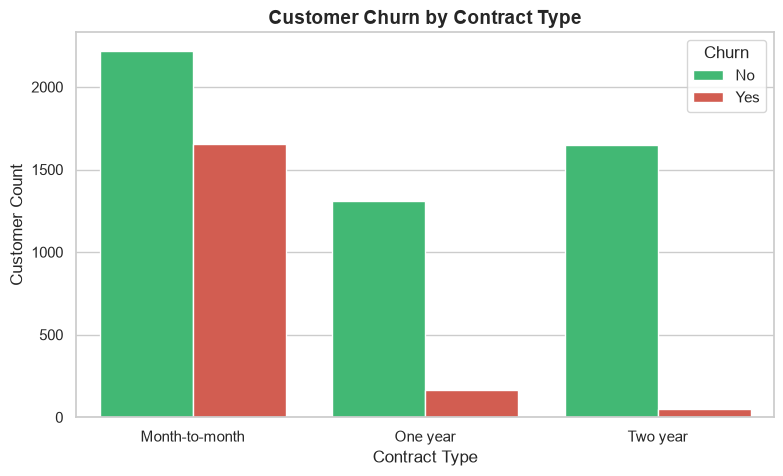

In [4]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')
plt.show()

### 3. Customer Tenure Loyalty vs. Churn Risk
Analyzing how customer tenure (in months) affects their probability of leaving.

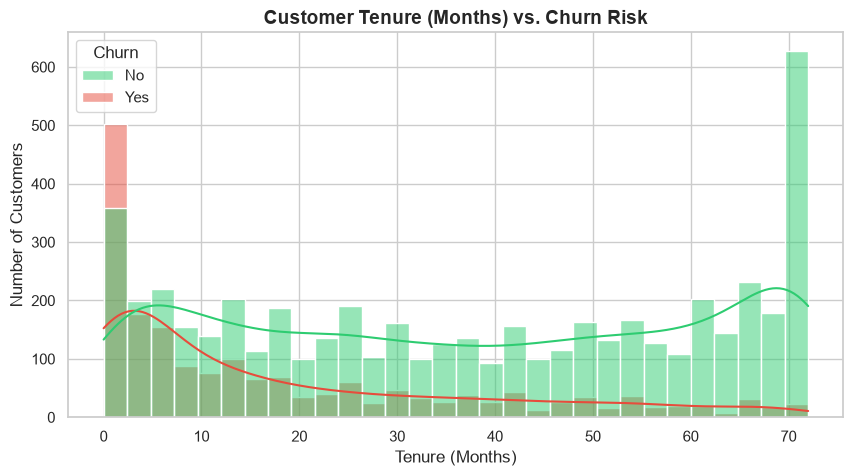

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30, palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Tenure (Months) vs. Churn Risk', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

### 4. Monthly Charges Distribution: Retained vs. Churned
Analyzing price sensitivity and monthly spending patterns.

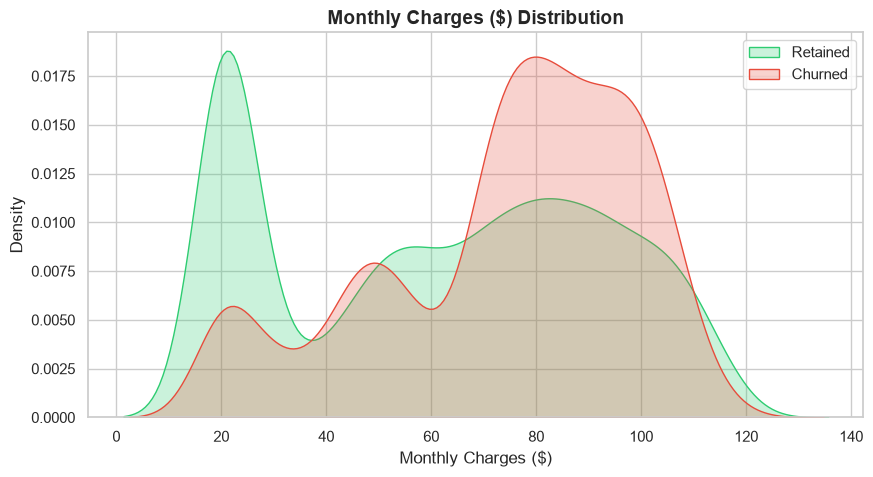

In [6]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['Churn']=='No']['MonthlyCharges'], label='Retained', color='#2ecc71', fill=True)
sns.kdeplot(data=df[df['Churn']=='Yes']['MonthlyCharges'], label='Churned', color='#e74c3c', fill=True)
plt.title('Monthly Charges ($) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.legend()
plt.show()